In [1]:
import os
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import above_library.surdat as surd
import above_library.plotting as plotting
import importlib

In [8]:
fig_dir = '/glade/work/afoster/ABoVE/figures'

In [2]:
surdat_dir = '/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/surfdata_esmf/ctsm5.3.0/'
surdat_file = 'surfdata_0.9x1.25_hist_2000_16pfts_c240908.nc'
surdat = xr.open_dataset(os.path.join(surdat_dir, surdat_file))

In [3]:
obs_dir = '/glade/work/afoster/ABoVE/obs_data'
obs_dat = pd.read_csv(os.path.join(obs_dir, 'site_averages.csv'), index_col=[0])
site_dat = obs_dat[['site', 'latitude', 'longitude']].drop_duplicates()

In [4]:
compiled_sites = surd.compile_site(site_dat, surdat)
combined_dat = surd.calculate_gridlevel_prop_BA(obs_dat, compiled_sites)

In [5]:
compiled_sites.to_csv(os.path.join(obs_dir, 'compiled_sites.csv'))
combined_dat.to_csv(os.path.join(obs_dir, 'combined_dat.csv'))

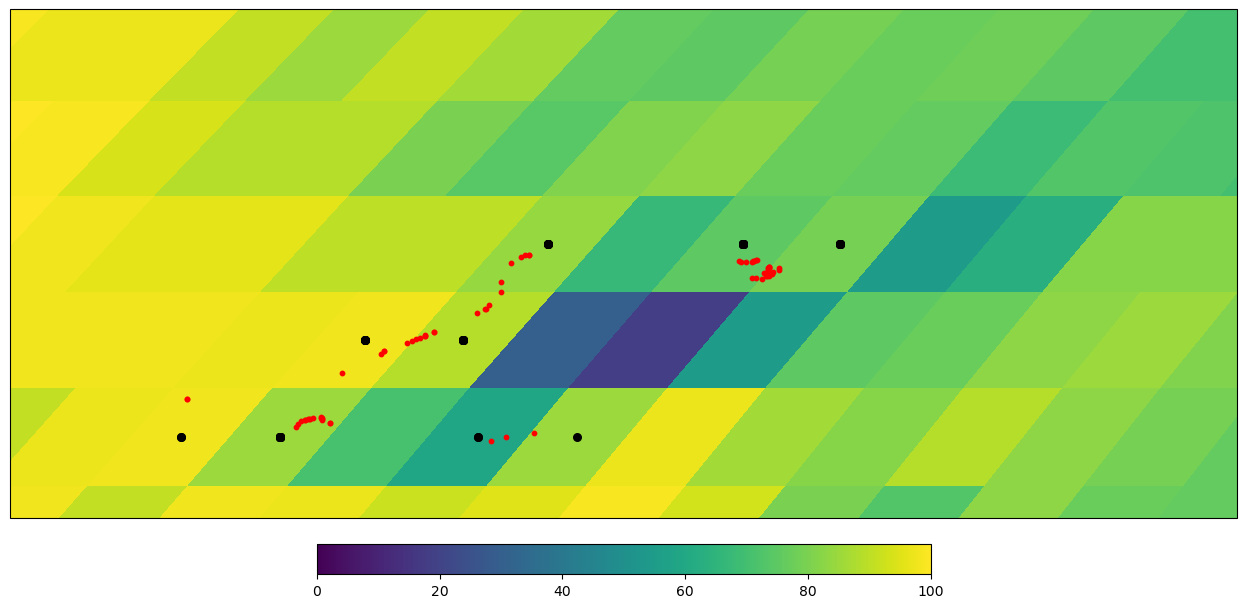

In [9]:
importlib.reload(plotting)
plotting.plot_it(surdat, 'PCT_NATVEG', compiled_sites, site_dat)
plt.savefig(os.path.join(fig_dir, 'grid_sites.png'))